13. This question should be answered using the Weekly data set, which is part of the ISLP package. This data is similar in nature to the Smarket data from this chapter’s lab, except that it contains 1, 089 weekly returns for 21 years, from the beginning of 1990 to the end of
2010

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ISLP import load_data

Weekly = load_data('Weekly')
Weekly.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


(a)

Produce some numerical and graphical summaries of the Weekly data. Do there appear to be any patterns?

In [17]:
# (a)
# 數值變數摘要
summary_stats = Weekly.describe()
print(summary_stats)

# 類別變數分佈
print("\nDirection value counts:")
print(Weekly['Direction'].value_counts())

# 相關係數矩陣（排除 Direction）
corr_matrix = Weekly.drop(columns='Direction').corr()
print("\nCorrelation matrix:")
print(corr_matrix)

              Year         Lag1         Lag2         Lag3         Lag4  \
count  1089.000000  1089.000000  1089.000000  1089.000000  1089.000000   
mean   2000.048669     0.150585     0.151079     0.147205     0.145818   
std       6.033182     2.357013     2.357254     2.360502     2.360279   
min    1990.000000   -18.195000   -18.195000   -18.195000   -18.195000   
25%    1995.000000    -1.154000    -1.154000    -1.158000    -1.158000   
50%    2000.000000     0.241000     0.241000     0.241000     0.238000   
75%    2005.000000     1.405000     1.409000     1.409000     1.409000   
max    2010.000000    12.026000    12.026000    12.026000    12.026000   

              Lag5       Volume        Today  
count  1089.000000  1089.000000  1089.000000  
mean      0.139893     1.574618     0.149899  
std       2.361285     1.686636     2.356927  
min     -18.195000     0.087465   -18.195000  
25%      -1.166000     0.332022    -1.154000  
50%       0.234000     1.002680     0.241000  
75% 

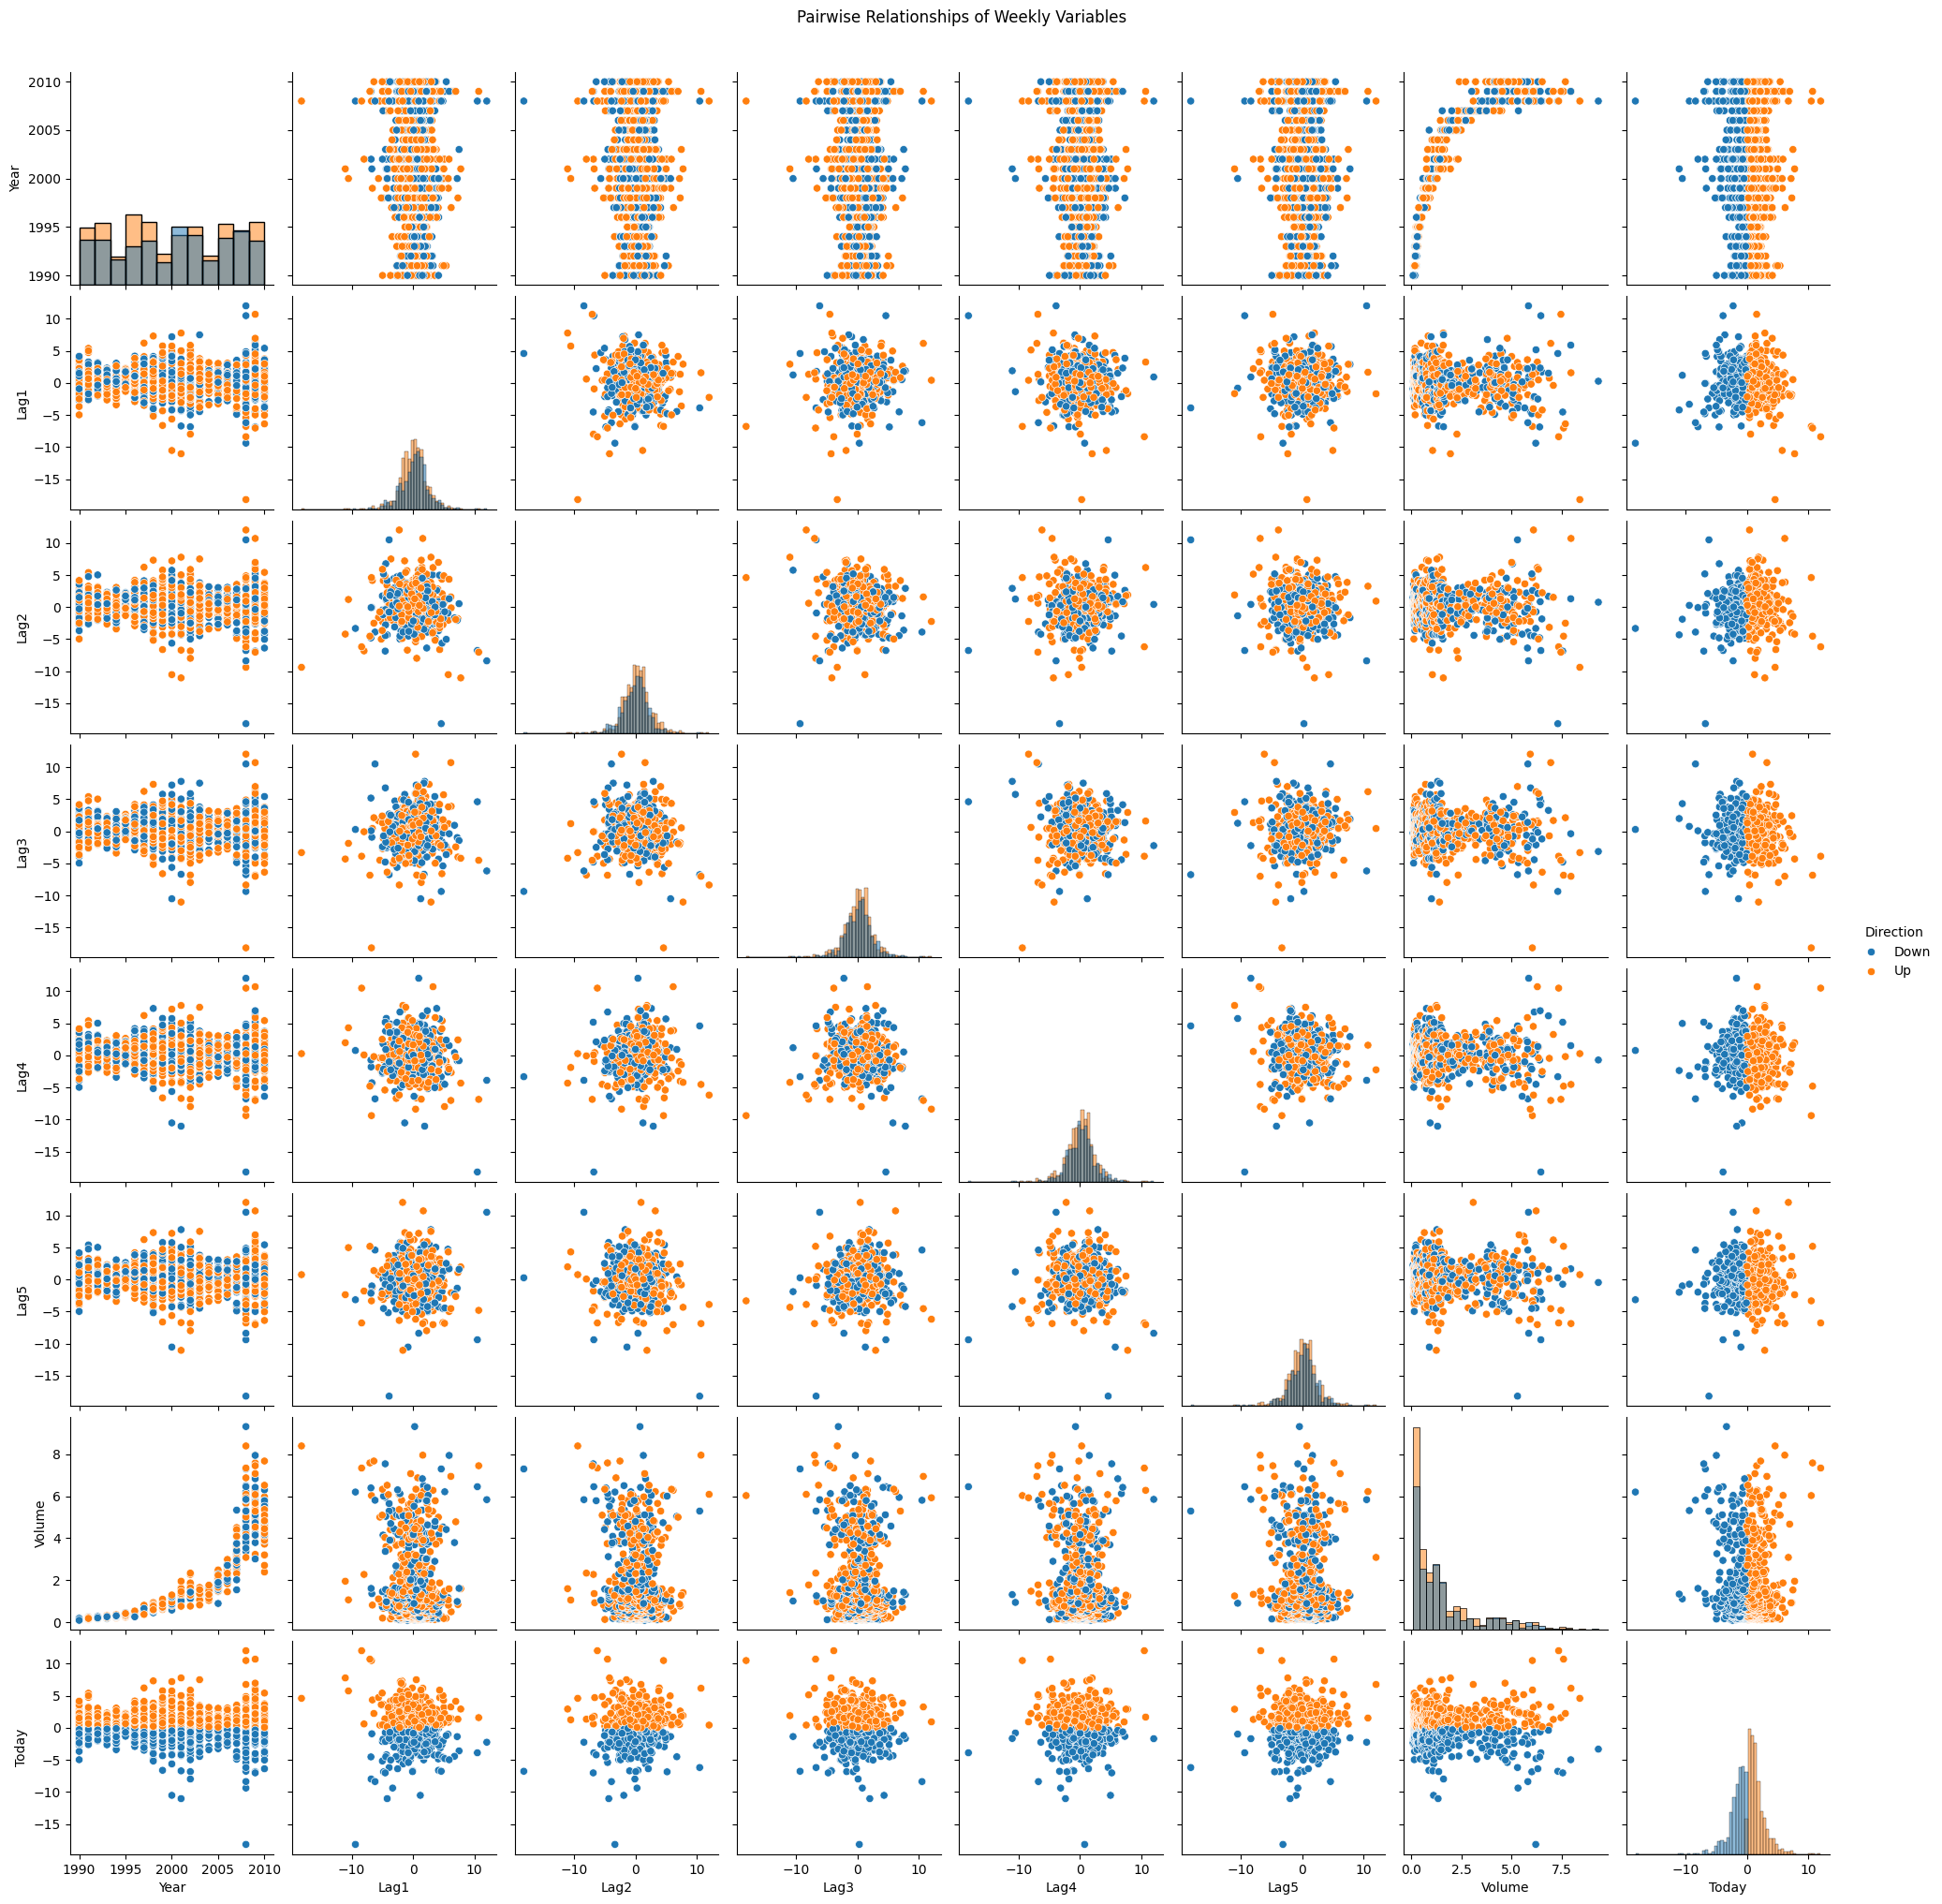

In [18]:
# 散點圖矩陣
sns.pairplot(Weekly, diag_kind="hist", hue="Direction")
plt.suptitle("Pairwise Relationships of Weekly Variables", y=1.02)
plt.show()

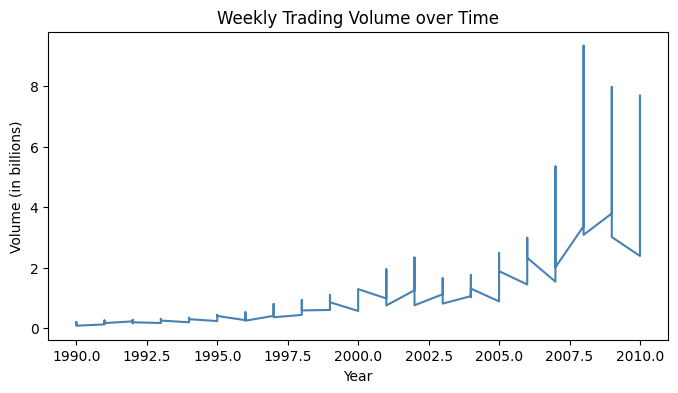

In [19]:
# 交易量隨時間變化
plt.figure(figsize=(8,4))
plt.plot(Weekly["Year"], Weekly["Volume"], color="steelblue")
plt.title("Weekly Trading Volume over Time")
plt.xlabel("Year")
plt.ylabel("Volume (in billions)")
plt.show()

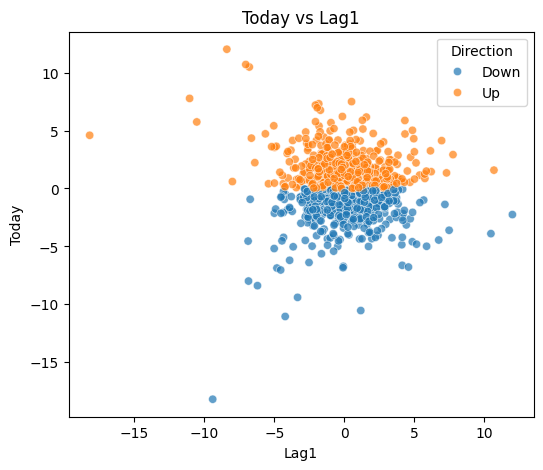

In [20]:
# Today vs Lag1 散點圖
plt.figure(figsize=(6,5))
sns.scatterplot(data=Weekly, x="Lag1", y="Today", hue="Direction", alpha=0.7)
plt.title("Today vs Lag1")
plt.show()

Weekly 資料呈現市場報酬的隨機特性，Volume 是唯一呈長期上升的變數。
報酬間的自相關極弱，因此僅靠過去報酬難以預測未來報酬。

(b)

Use the full data set to perform a logistic regression with Direction as the response and the five lag variables plus Volume as predictors. Use the summary function to print the results. Do any of the predictors appear to be statistically significant? If so, which ones?

In [21]:
# (b)
import statsmodels.api as sm

# 將 Direction 轉為二元變數：Up = 1, Down = 0
Weekly['Direction_binary'] = (Weekly['Direction'] == 'Up').astype(int)

# 定義自變數與應變數
X = Weekly[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']]
X = sm.add_constant(X)  # 加入截距項
y = Weekly['Direction_binary']

# 建立邏輯迴歸模型
logit_model = sm.Logit(y, X)
result = logit_model.fit()

# 輸出摘要
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.682441
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:       Direction_binary   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1082
Method:                           MLE   Df Model:                            6
Date:                Sun, 02 Nov 2025   Pseudo R-squ.:                0.006580
Time:                        13:00:39   Log-Likelihood:                -743.18
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.1313
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.

	•	僅 Lag2 為顯著變數（p ≈ 0.030）。
    → 表示兩週前的報酬對本週上漲機率有微弱的正向關係。
	•	其他 Lag 與 Volume 皆無統計顯著性。

(c)

Compute the confusion matrix and overall fraction of correct predictions. Explain what the confusion matrix is telling you. about the types of mistakes made by logistic regression.

In [22]:
# (c)
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score

# 使用前面建立好的模型 result
pred_probs = result.predict(X)                  # 機率預測
pred_class = np.where(pred_probs > 0.5, 1, 0)   # 閾值0.5 -> 分類結果

# 混淆矩陣
cm = confusion_matrix(y, pred_class)
acc = accuracy_score(y, pred_class)

print("Confusion Matrix:")
print(cm)
print("\nOverall Accuracy:", round(acc, 4))

Confusion Matrix:
[[ 54 430]
 [ 48 557]]

Overall Accuracy: 0.5611


	•	整體準確率：約 56.1%
    （略高於隨機猜測 50%）
	•	錯誤類型：
	  1.模型 傾向預測上漲 (Up)，導致許多實際下跌週被錯判為上漲。
	  2.對下跌 (Down) 的辨識能力弱。
	•	原因：
	  1.因 Up 比例佔多（605 vs 484），模型傾向學習到偏向上漲的決策邏輯。
	  2.變數之間相關性弱，導致模型預測力有限。

(d)

Now fit the logistic regression model using a training data period from 1990 to 2008, with Lag2 as the only predictor. Compute the confusion matrix and the overall fraction of correct predictions for the held out data (that is, the data from 2009 and 2010).

In [23]:
# (d)

# 分割訓練 / 測試集
train = Weekly[Weekly['Year'] <= 2008]
test = Weekly[Weekly['Year'] > 2008]

# 訓練模型：Direction ~ Lag2
X_train = sm.add_constant(train['Lag2'])
y_train = train['Direction_binary']

X_test = sm.add_constant(test['Lag2'])
y_test = test['Direction_binary']

# 建立 logistic regression 模型
logit_model_d = sm.Logit(y_train, X_train)
result_d = logit_model_d.fit()

print(result_d.summary())

# 測試集預測
pred_probs_d = result_d.predict(X_test)
pred_class_d = np.where(pred_probs_d > 0.5, 1, 0)

# 混淆矩陣與準確率
cm_d = confusion_matrix(y_test, pred_class_d)
acc_d = accuracy_score(y_test, pred_class_d)

print("\nConfusion Matrix (Test 2009–2010):")
print(cm_d)
print("\nOverall Accuracy:", round(acc_d, 4))

Optimization terminated successfully.
         Current function value: 0.685555
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:       Direction_binary   No. Observations:                  985
Model:                          Logit   Df Residuals:                      983
Method:                           MLE   Df Model:                            1
Date:                Sun, 02 Nov 2025   Pseudo R-squ.:                0.003076
Time:                        13:01:21   Log-Likelihood:                -675.27
converged:                       True   LL-Null:                       -677.35
Covariance Type:            nonrobust   LLR p-value:                   0.04123
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2033      0.064      3.162      0.002       0.077       0.329
Lag2           0.0581      0.